In [71]:
#importer les libs
import sys; sys.path.insert(0, '..') #pour importer depuis src/ et config.py
from vectorbtpro import *
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png" #rendre en PNG sinon vscode crash avec les gros json plotly

## 1. Charger les résultats d'optimisation

In [ ]:
#charger le pickle generé par opti.py
#le pickle contient les sharpe de chaque combo pour chaque fenetre (train + test)
#changer le nom du fichier selon la paire/tf/exchange qu'on veut analyser
CACHE_FILE = '../cache/kc_wfsl_BTCUSDT_1h_binance.pickle'
results = vbt.load(CACHE_FILE)
print(f"{len(results)} resultats chargés")
results.head(10)

## 2. Séparation train / test

In [73]:
#separer train et test pour les comparer
train_results = results.xs('train', level='set')
test_results = results.xs('test', level='set')

print(f"Train : {len(train_results)} resultats")
print(f"Test : {len(test_results)} resultats")
print(f"NaN dans train : {train_results.isna().sum()} (combos qui ont pas tourné)")
print(f"NaN dans test : {test_results.isna().sum()}")

Train : 82320 resultats
Test : 82320 resultats
NaN dans train : 0 (combos qui ont pas tourné)
NaN dans test : 0


## 3. Corrélation train / test

In [74]:
#correlation entre sharpe train et sharpe test
#positif = les bons params en train sont aussi bons en test = pas d'overfitting
#negatif = les bons params en train sont mauvais en test = overfitting
corr = train_results.corr(test_results)
print(f"Correlation train/test : {corr:.4f}")

if corr > 0.5:
    print("Bonne correlation, les resultats generalisent bien")
elif corr > 0:
    print("Correlation faible, risque d'overfitting modéré")
else:
    print("Correlation negative, overfitting probable")

Correlation train/test : 0.8994
Bonne correlation, les resultats generalisent bien


## 4. Heatmap Sharpe médian (train) — ma_window vs atr_mult

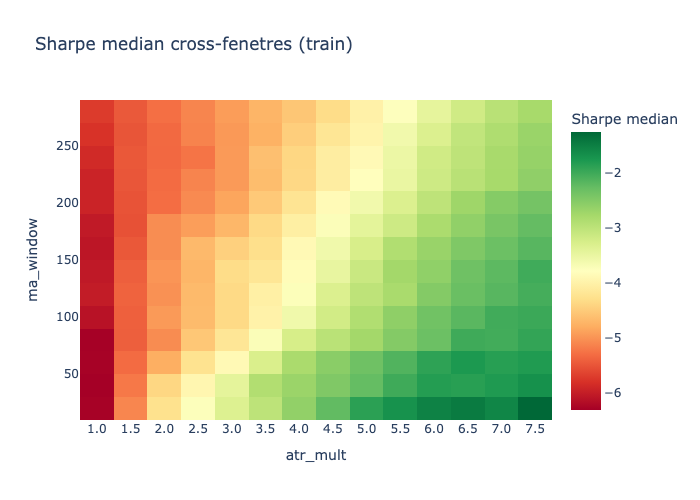

In [75]:
#heatmap sharpe median sur le train
#chaque case = mediane du sharpe sur toutes les fenetres pour cette paire (ma_window, atr_mult)
#on agrege sur atr_window et sl_stop pour voir la tendance generale
median_sharpe = train_results.groupby(level=['ma_window', 'atr_mult']).median()
heatmap_data = median_sharpe.unstack(level='atr_mult') #pivot pour avoir atr_mult en colonnes

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=[f'{x:.1f}' for x in heatmap_data.columns],
    y=heatmap_data.index,
    colorscale='RdYlGn', #rouge = mauvais, vert = bon
    colorbar=dict(title='Sharpe median')
))
fig.update_layout(
    title='Sharpe median cross-fenetres (train)',
    xaxis_title='atr_mult', yaxis_title='ma_window', height=500
)
fig.show()

## 5. Heatmap différence test - train (overfitting check)

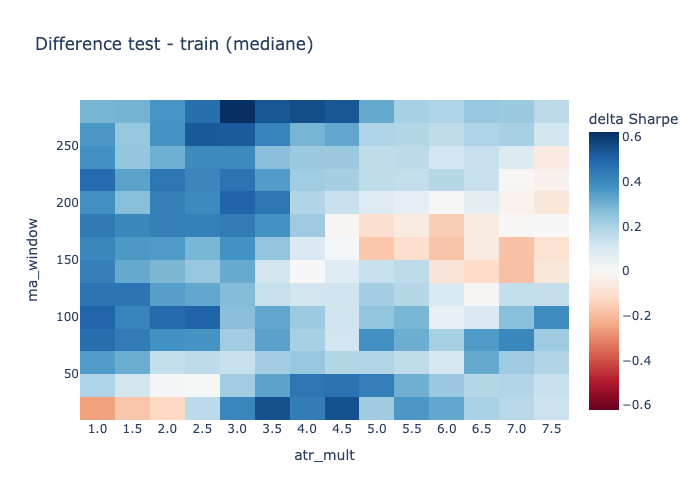

In [76]:
#heatmap de la diff entre test et train
#bleu = le test fait MIEUX que le train, bonne generalisation
#rouge = le test fait MOINS bien, overfitting sur ces params
diff = test_results - train_results
median_diff = diff.groupby(level=['ma_window', 'atr_mult']).median()
diff_matrix = median_diff.unstack(level='atr_mult')

fig = go.Figure(data=go.Heatmap(
    z=diff_matrix.values,
    x=[f'{x:.1f}' for x in diff_matrix.columns],
    y=diff_matrix.index,
    colorscale='RdBu', zmid=0, #centré sur 0, bleu positif rouge negatif
    colorbar=dict(title='delta Sharpe')
))
fig.update_layout(
    title='Difference test - train (mediane)',
    xaxis_title='atr_mult', yaxis_title='ma_window', height=500
)
fig.show()

## 6. Recherche de combos robustes

In [77]:
#trouver les combos robustes
#robuste = sharpe > 0 sur au moins 50% des fenetres de train
param_levels = ['ma_window', 'atr_window', 'atr_mult', 'sl_stop']

#pour chaque combo, compter combien de fenetres ont un sharpe > 0
positive_counts = train_results.groupby(level=param_levels).apply(
    lambda x: (x.dropna() > 0).sum()
)
#sharpe median par combo (agregé sur les fenetres)
median_sharpes = train_results.groupby(level=param_levels).median()

n_splits = results.index.get_level_values('split').nunique() #nb de fenetres
robust = positive_counts[positive_counts >= n_splits * 0.5] #garder que les combos robustes
print(f"{len(robust)} combos robustes sur {len(positive_counts)} total")

if len(robust) > 0:
    #parmi les robustes, prendre celle avec le meilleur sharpe median
    robust_medians = median_sharpes.loc[robust.index]
    best_robust = robust_medians.idxmax()
    final_ma, final_atrw, final_atrm, final_sl = best_robust
    final_ma, final_atrw = int(final_ma), int(final_atrw)
    print(f"\nMeilleure combo robuste :")
    print(f"  ma_window={final_ma}, atr_window={final_atrw}, atr_mult={final_atrm}, sl_stop={final_sl}")
    print(f"  Sharpe median train : {robust_medians.loc[best_robust]:.2f}")
    print(f"  Fenetres positives : {robust.loc[best_robust]}/{n_splits}")
else:
    #fallback si aucune combo robuste, on prend quand meme la meilleure
    best_robust = median_sharpes.idxmax()
    final_ma, final_atrw, final_atrm, final_sl = best_robust
    final_ma, final_atrw = int(final_ma), int(final_atrw)
    print(f"\nAucune combo robuste, fallback sur le meilleur sharpe median :")
    print(f"  ma_window={final_ma}, atr_window={final_atrw}, atr_mult={final_atrm}, sl_stop={final_sl}")
    print(f"  Sharpe median : {median_sharpes.loc[best_robust]:.2f}")

#verifier la perf de cette combo sur le test (données jamais vues)
test_medians = test_results.groupby(level=param_levels).median()
test_val = test_medians.loc[(final_ma, final_atrw, final_atrm, final_sl)]
print(f"  Sharpe median test : {test_val:.2f}")

0 combos robustes sur 8232 total

Aucune combo robuste, fallback sur le meilleur sharpe median :
  ma_window=20, atr_window=30, atr_mult=7.5, sl_stop=0.12
  Sharpe median : -0.76
  Sharpe median test : -0.32


## 7. Performance sur le test (out-of-sample)

In [78]:
#perf de la meilleure combo sur chaque fenetre de test (out-of-sample)
#c'est ca le vrai test, est ce que les params marchent sur des données jamais vues
test_perf = test_results.xs(
    (final_ma, final_atrw, final_atrm, final_sl),
    level=param_levels
)
print('Sharpe test par fenetre :')
print(test_perf)
print(f"\nMoyen : {test_perf.mean():.2f}")
print(f"Median : {test_perf.median():.2f}")
print(f"Positifs : {(test_perf > 0).sum()}/{len(test_perf)}") #combien de fenetres sont rentables

Sharpe test par fenetre :
split
0   -0.804413
1   -0.334307
2    0.028806
3    0.594255
4   -1.551491
5   -1.961393
6   -1.788631
7    0.389096
8    0.748182
9   -0.298927
dtype: float64

Moyen : -0.50
Median : -0.32
Positifs : 4/10


## 8. Backtest final sur tout le dataset

In [ ]:
from src.strategies.keltner import run_backtest

#extraire pair/tf/exchange du nom du pickle
_cache_name = os.path.basename(CACHE_FILE).replace('kc_wfsl_', '').replace('.pickle', '')
_pair, _tf, _exchange = _cache_name.split('_')

#charger les données (meme symbole que dans le pickle)
data = pd.read_csv(f'../data/raw/{_exchange}/{_tf}/{_pair}.csv')
data['date'] = pd.to_datetime(data['date'], unit='ms')
data = data.set_index('date')

#bt sur TOUT le dataset avec les params trouvés
#attention c'est du in-sample car les params viennent de ces memes données
pf_final = run_backtest(data, final_ma, final_atrw, final_atrm, final_sl, size=1)
print(pf_final.stats())

## 9. Top 10 des meilleures combos

In [80]:
#top 10 des meilleures combos par sharpe median sur le train
#on ajoute le sharpe test pour voir si ca tient ou si c'est de l'overfitting
top10 = median_sharpes.sort_values(ascending=False).head(10)
top10_df = top10.reset_index()
top10_df.columns = ['ma_window', 'atr_window', 'atr_mult', 'sl_stop', 'sharpe_train']

#recuperer le sharpe test correspondant a chaque combo du top 10
top10_df['sharpe_test'] = [test_medians.loc[tuple(row[:-1])] for _, row in top10_df.iterrows()]
top10_df['delta'] = top10_df['sharpe_test'] - top10_df['sharpe_train'] #delta negatif = overfitting

print("Top 10 combos (train) avec perf test :")
top10_df

Top 10 combos (train) avec perf test :


,ma_window,atr_window,atr_mult,sl_stop,sharpe_train,sharpe_test,delta
0,20,30,7.5,0.12,-0.755248,-0.316617,0.438631
1,20,10,7.5,0.12,-0.852619,-0.624102,0.228517
2,20,60,6.0,0.12,-0.894465,-0.942429,-0.047964
3,20,30,7.5,0.06,-0.909165,-0.371598,0.537567
4,20,10,7.5,0.06,-0.914019,-0.969452,-0.055433
5,20,30,7.5,0.10,-0.914714,-0.435254,0.479460
6,20,60,6.0,0.10,-0.927762,-0.859632,0.068130
7,180,10,7.5,0.12,-0.959082,-0.808795,0.150286
8,20,20,5.5,0.12,-0.984348,-0.707952,0.276395
9,100,10,6.5,0.10,-1.000151,-0.993754,0.006397


## 10. Ranking multi-paires (scan multi)
Charge tous les pickles du cache et compare les paires entre elles.
Skip cette section si t'as qu'un seul pickle (mode single).

In [ ]:
#charger tous les pickles du cache
import glob

pickle_files = glob.glob('../cache/kc_wfsl_*.pickle')
print(f"{len(pickle_files)} fichiers trouvés dans le cache")

if len(pickle_files) <= 1:
    print("Un seul pickle, rien a comparer (lance opti.py en mode multi)")
else:
    ranking = []

    for f in sorted(pickle_files):
        #extraire pair/tf/exchange du nom du fichier
        name = os.path.basename(f).replace('kc_wfsl_', '').replace('.pickle', '')
        parts = name.split('_')
        if len(parts) != 3:
            continue
        p, t, ex = parts

        res = vbt.load(f)
        train = res.xs('train', level='set')
        test = res.xs('test', level='set')

        param_levels = ['ma_window', 'atr_window', 'atr_mult', 'sl_stop']
        n_splits = res.index.get_level_values('split').nunique()

        #compter les combos robustes (sharpe > 0 sur 50%+ des fenetres)
        pos_counts = train.groupby(level=param_levels).apply(lambda x: (x.dropna() > 0).sum())
        n_robust = (pos_counts >= n_splits * 0.5).sum()

        #meilleur sharpe median train et test correspondant
        med_train = train.groupby(level=param_levels).median()
        med_test = test.groupby(level=param_levels).median()
        best_idx = med_train.idxmax()
        best_train = med_train.loc[best_idx]
        best_test = med_test.loc[best_idx]

        #correlation train/test
        corr = train.corr(test)

        ranking.append({
            'pair': p, 'tf': t, 'exchange': ex,
            'combos_robustes': n_robust,
            'best_sharpe_train': round(best_train, 3),
            'best_sharpe_test': round(best_test, 3),
            'delta': round(best_test - best_train, 3),
            'corr_train_test': round(corr, 3),
            'best_params': best_idx,
        })

    ranking_df = pd.DataFrame(ranking)
    #trier par sharpe test decroissant
    ranking_df = ranking_df.sort_values('best_sharpe_test', ascending=False).reset_index(drop=True)
    print("\nRanking des paires (trié par sharpe test) :")
    ranking_df[['pair', 'tf', 'exchange', 'combos_robustes',
                'best_sharpe_train', 'best_sharpe_test', 'delta', 'corr_train_test']]

In [ ]:
#visu du ranking si on a les données
if len(pickle_files) > 1 and len(ranking) > 0:
    fig = go.Figure()
    for _, row in ranking_df.iterrows():
        label = f"{row['pair']} {row['tf']}"
        fig.add_trace(go.Bar(
            name=label,
            x=[label],
            y=[row['best_sharpe_test']],
            marker_color='green' if row['best_sharpe_test'] > 0 else 'red',
        ))
    fig.update_layout(
        title='Sharpe test par paire/tf (meilleure combo)',
        yaxis_title='Sharpe ratio (test)',
        showlegend=False, height=400,
    )
    fig.add_hline(y=0, line_dash='dash', line_color='gray')
    fig.show()